<a href="https://colab.research.google.com/github/Puja29D/A-B-Testing-Regression-Analysis/blob/main/A_B_Testing_%26_Regression_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import coint
from scipy import stats as st
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("/content/A_B_testing_dataset.csv")

In [3]:
df.head(5)

,date_of_campaign,facebook_ad_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click,adword_ad_campaign,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad,adword_ctr,adword_conversion_rate,adword_cost_per_click
0,2021-12-22,FACEBOOK AD,3172,62,14,141,1.95,22.58,2.27,ADWORD AD,5754,64,9,177,1.11,14.06,2.77
1,2021-12-24,FACEBOOK AD,3211,38,9,186,1.18,23.68,4.89,ADWORD AD,4954,73,6,54,1.47,8.22,0.74
2,2021-12-25,FACEBOOK AD,1936,53,15,66,2.74,28.30,1.25,ADWORD AD,4702,38,9,187,0.81,23.68,4.92
3,2021-12-25,FACEBOOK AD,1194,45,9,71,3.77,20.00,1.58,ADWORD AD,3718,58,3,161,1.56,5.17,2.78
4,2021-12-26,FACEBOOK AD,2479,44,12,174,1.77,27.27,3.95,ADWORD AD,5562,63,4,162,1.13,6.35,2.57


In [4]:
df.shape

(1000, 17)

In [5]:
df.columns

Index(['date_of_campaign', 'facebook_ad_campaign', 'facebook_ad_views',
       'facebook_ad_clicks', 'facebook_ad_conversions', 'facebook_cost_per_ad',
       'facebook_ctr', 'facebook_conversion_rate', 'facebook_cost_per_click',
       'adword_ad_campaign', 'adword_ad_views', 'adword_ad_clicks',
       'adword_ad_conversions', 'adword_cost_per_ad', 'adword_ctr',
       'adword_conversion_rate', 'adword_cost_per_click'],
      dtype='object')

In [6]:
df.dtypes

,0
date_of_campaign,object
facebook_ad_campaign,object
facebook_ad_views,int64
facebook_ad_clicks,int64
facebook_ad_conversions,int64
facebook_cost_per_ad,int64
facebook_ctr,float64
facebook_conversion_rate,float64
facebook_cost_per_click,float64
adword_ad_campaign,object


In [7]:
df.isnull().sum()

,0
date_of_campaign,0
facebook_ad_campaign,0
facebook_ad_views,0
facebook_ad_clicks,0
facebook_ad_conversions,0
facebook_cost_per_ad,0
facebook_ctr,0
facebook_conversion_rate,0
facebook_cost_per_click,0
adword_ad_campaign,0


In [8]:
df.describe()

,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad,adword_ctr,adword_conversion_rate,adword_cost_per_click
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2152.031000,44.196000,11.975000,156.610000,2.28316,32.696080,4.310500,4771.438000,60.128000,5.933000,124.741000,1.280950,10.807510,2.265540
std,661.982166,16.833328,4.298471,54.918904,1.20670,20.570796,2.751582,598.647684,17.047822,2.011606,43.809053,0.402492,5.205133,1.101846
min,1050.000000,15.000000,5.000000,60.000000,0.49000,6.850000,0.960000,3715.000000,31.000000,3.000000,50.000000,0.540000,3.370000,0.580000
25%,1600.250000,30.000000,8.000000,110.000000,1.36750,18.052500,2.337500,4258.250000,45.000000,4.000000,86.000000,0.940000,6.970000,1.470000
50%,2123.500000,44.500000,12.000000,156.000000,2.07000,27.120000,3.600000,4808.500000,60.000000,6.000000,124.000000,1.260000,9.720000,2.030000
75%,2706.250000,58.000000,16.000000,205.000000,2.92250,41.880000,5.610000,5300.750000,75.000000,8.000000,163.000000,1.570000,13.485000,2.802500
max,3320.000000,73.000000,19.000000,250.000000,6.86000,118.750000,16.530000,5754.000000,89.000000,9.000000,200.000000,2.370000,29.030000,6.190000


In [9]:
df["date_of_campaign"]=pd.to_datetime(df["date_of_campaign"])

In [10]:
df.head()

,date_of_campaign,facebook_ad_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click,adword_ad_campaign,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad,adword_ctr,adword_conversion_rate,adword_cost_per_click
0,2021-12-22,FACEBOOK AD,3172,62,14,141,1.95,22.58,2.27,ADWORD AD,5754,64,9,177,1.11,14.06,2.77
1,2021-12-24,FACEBOOK AD,3211,38,9,186,1.18,23.68,4.89,ADWORD AD,4954,73,6,54,1.47,8.22,0.74
2,2021-12-25,FACEBOOK AD,1936,53,15,66,2.74,28.30,1.25,ADWORD AD,4702,38,9,187,0.81,23.68,4.92
3,2021-12-25,FACEBOOK AD,1194,45,9,71,3.77,20.00,1.58,ADWORD AD,3718,58,3,161,1.56,5.17,2.78
4,2021-12-26,FACEBOOK AD,2479,44,12,174,1.77,27.27,3.95,ADWORD AD,5562,63,4,162,1.13,6.35,2.57


will check otutliers by ploting histogram

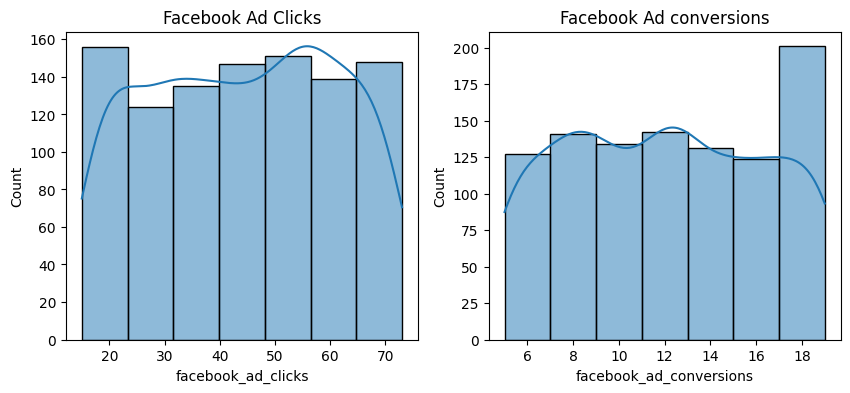

In [11]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df["facebook_ad_clicks"],bins= 7,edgecolor="k",kde=True )
plt.title("Facebook Ad Clicks")
plt.subplot(1,2,2)
sns.histplot(df["facebook_ad_conversions"],bins= 7,edgecolor="k",kde=True )
plt.title("Facebook Ad conversions")
plt.show()

Facebook ads generate consistent clicks, mostly between 40–60.

Those clicks convert into moderate conversions (8–15).

The distribution shows no major outliers, ad performance is stable and predictable.

A few ads have higher conversions, suggesting some campaigns performed better and can be analyzed further.

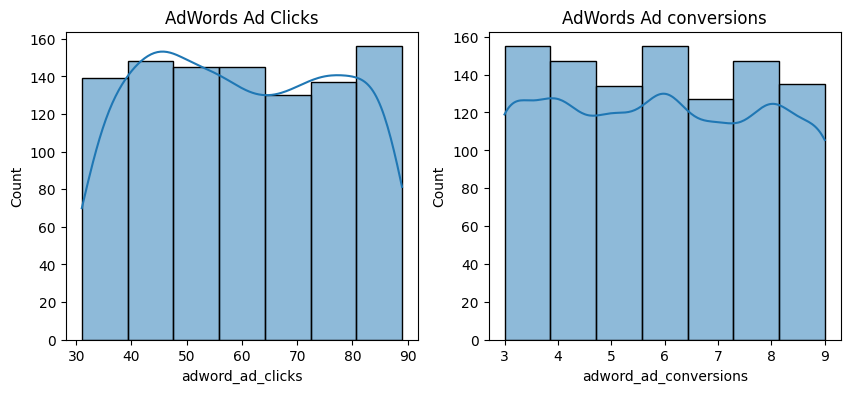

In [12]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df["adword_ad_clicks"],bins= 7,edgecolor="k",kde=True )
plt.title("AdWords Ad Clicks")
plt.subplot(1,2,2)
sns.histplot(df["adword_ad_conversions"],bins= 7,edgecolor="k",kde=True )
plt.title("AdWords Ad conversions")
plt.show()

AdWords ads receive higher click values (40–80), indicating strong user interest.

Conversions remain steady and predictable, mostly between 4–8.

A few ads perform exceptionally well in clicks (80–90 range)

**How frequenty observe days with higher number of conversion campare with days with lower number of conversion**

In [13]:
# creating function to calculate the category for the conversions
def create_conversion_category(conversion_col):
    category = []
    for conversion in df[conversion_col]:
        if conversion < 6:
            category.append('less than 6')
        elif 6 <= conversion <= 10:
            category.append('6 - 10')
        elif 11 <= conversion <= 15:
            category.append('11 - 15')
        else:
            category.append('more than 15')
    return category


# applying function on different campaign's conversions
df['Facebook Conversion Category'] = create_conversion_category('facebook_ad_conversions')
df['Adwords Conversion Category'] = create_conversion_category('adword_ad_conversions')


In [14]:
df[['facebook_ad_conversions','Facebook Conversion Category','adword_ad_conversions','Adwords Conversion Category']].head()

,facebook_ad_conversions,Facebook Conversion Category,adword_ad_conversions,Adwords Conversion Category
0,14,11 - 15,9,6 - 10
1,9,6 - 10,6,6 - 10
2,15,11 - 15,9,6 - 10
3,9,6 - 10,3,less than 6
4,12,11 - 15,4,less than 6


In [15]:
df['Facebook Conversion Category'].value_counts()

,count
Facebook Conversion Category,
11 - 15,341
6 - 10,337
more than 15,257
less than 6,65


In [16]:
facebook=pd.DataFrame(df['Facebook Conversion Category'].value_counts()).reset_index().rename(columns={'Facebook Conversion Category':'Category'})
facebook

,Category,count
0,11 - 15,341
1,6 - 10,337
2,more than 15,257
3,less than 6,65


In [17]:
df['Adwords Conversion Category'].value_counts()

,count
Adwords Conversion Category,
6 - 10,564
less than 6,436


In [18]:
adwords=pd.DataFrame(df['Adwords Conversion Category'].value_counts()).reset_index().rename(columns={'Adwords Conversion Category':'Category'})
adwords

,Category,count
0,6 - 10,564
1,less than 6,436


In [19]:
category_df=pd.merge(facebook, adwords, on='Category', how='outer').fillna(0)
category_df

,Category,count_x,count_y
0,11 - 15,341,0.0
1,6 - 10,337,564.0
2,less than 6,65,436.0
3,more than 15,257,0.0


In [20]:
category_df = category_df.iloc[[3, 1, 0, 2]]
category_df


,Category,count_x,count_y
3,more than 15,257,0.0
1,6 - 10,337,564.0
0,11 - 15,341,0.0
2,less than 6,65,436.0


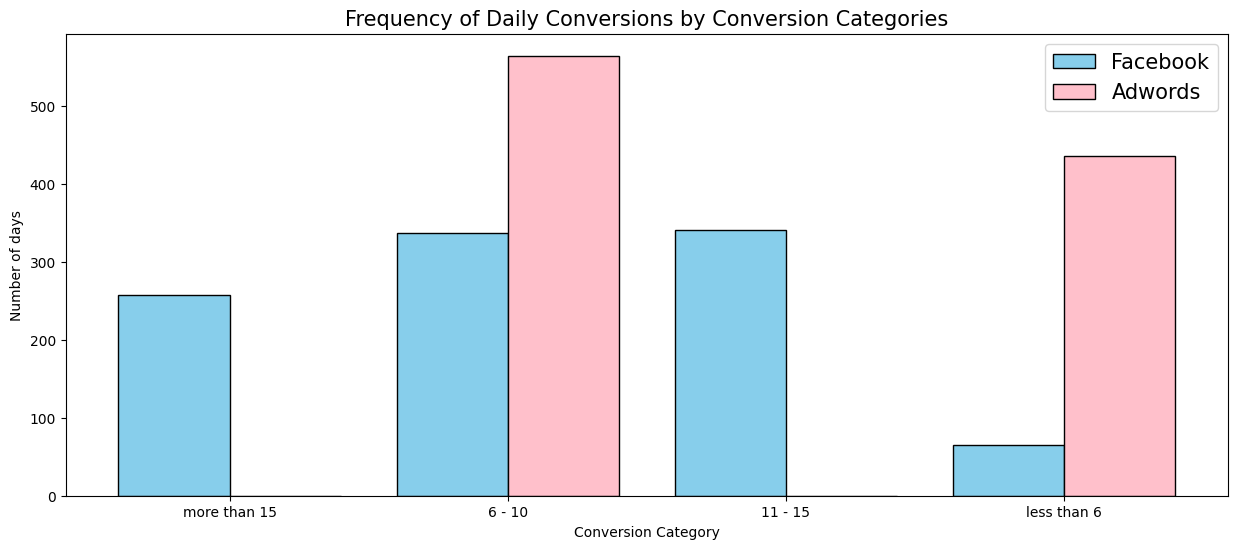

In [21]:
# X-axis positions
X_axis = np.arange(len(category_df))

plt.figure(figsize=(15, 6))

# Bar for Facebook
plt.bar(X_axis - 0.2,
        category_df['count_x'],
        0.4,
        label='Facebook',
        color='skyblue',
        linewidth=1,
        edgecolor='k')

# Bar for Adwords
plt.bar(X_axis + 0.2,
        category_df['count_y'],
        0.4,
        label='Adwords',
        color='pink',
        linewidth=1,
        edgecolor='k')

# X-axis category names
plt.xticks(X_axis, category_df['Category'])

plt.xlabel("Conversion Category")
plt.ylabel("Number of days")

plt.title("Frequency of Daily Conversions by Conversion Categories", fontsize=15)

plt.legend(fontsize=15)
plt.show()


Facebook has more days in the categories 6–10 and 11–15 conversions.

Adwords has the highest number of days in the 6–10 and less than 6 categories.

In the more than 15 category, only Facebook has conversions (Adwords has zero).

In the 11–15 category, only Facebook appears — Adwords has zero days.

### Do more click on ad means more sales?

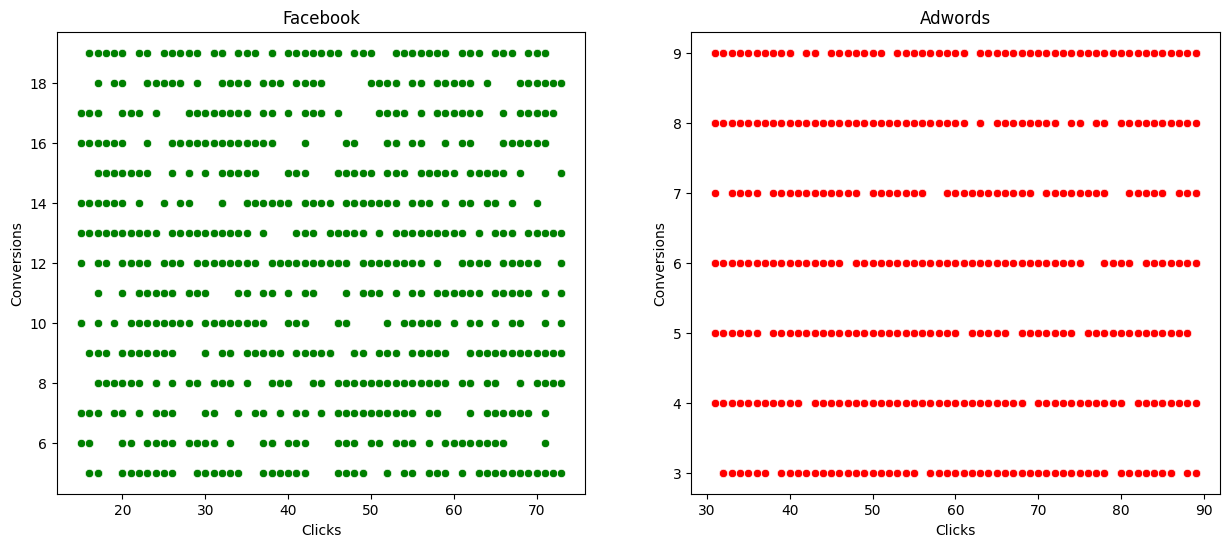

In [22]:
plt.figure(figsize=(15,6))


plt.subplot(1, 2, 1)
plt.title('Facebook')
sns.scatterplot(
    x = df['facebook_ad_clicks'],
    y = df['facebook_ad_conversions'],
    color = 'green'
)
plt.xlabel('Clicks')
plt.ylabel('Conversions')


plt.subplot(1, 2, 2)
plt.title('Adwords')
sns.scatterplot(
    x = df['adword_ad_clicks'],
    y = df['adword_ad_conversions'],
    color = 'red'
)
plt.xlabel('Clicks')
plt.ylabel('Conversions')

plt.show()


Both platforms show weak relationships

Increasing clicks does NOT guarantee higher conversions

In [23]:
facebook_corr=df[['facebook_ad_conversions','facebook_ad_clicks']].corr()
facebook_corr

,facebook_ad_conversions,facebook_ad_clicks
facebook_ad_conversions,1.000000,-0.005009
facebook_ad_clicks,-0.005009,1.000000


In [24]:
adword_Corr=df[['adword_ad_conversions','adword_ad_clicks']].corr()
adword_Corr

,adword_ad_conversions,adword_ad_clicks
adword_ad_conversions,1.000000,0.004162
adword_ad_clicks,0.004162,1.000000


In [25]:
print('Correlation Coeff \n------------------')
print('Facebook : ', round(facebook_corr.values[0,1], 2))
print('AdWords : ', round(adword_Corr.values[0,1], 2))


Correlation Coeff 
------------------
Facebook :  -0.01
AdWords :  0.0


For both Facebook and AdWords, clicks do not influence conversions.

High clicks do NOT guarantee high conversions.

Low clicks do NOT mean low conversions.

Conversions happen independently of clicks.

## Hypothesis Testing

Null Hypothesis (H0):There is no difference in number of conversion between facebook and adwords,or the number of conversion from adwords is greater than or equal to those from facebook.
H0:μfacebook <= μadwords

Alternative Hypothesis (H1):the number of conversion from facebook is greater than number of conversion from adwords.
H1:μfacebook > μadwords


In [26]:
print("mean conversion \n------------------")
print("facebook_mean:",round(df["facebook_ad_conversions"].mean(),2))
print("adwords_mean:",round(df["adword_ad_conversions"].mean(),2))


mean conversion 
------------------
facebook_mean: 11.98
adwords_mean: 5.93


In [27]:
#Independent t-test
t_stat,p_value=st.ttest_ind(df["facebook_ad_conversions"],df["adword_ad_conversions"])
print("t_stat:",t_stat)
print("p_value:",p_value)

if p_value<0.05:
     print("Reject the null hypothesis")
else:
     print("Fail to reject the null hypothesis")

t_stat: 40.25906231407935
p_value: 5.194664900443779e-260
Reject the null hypothesis


Facebook conversions are significantly greater than AdWords conversions.

The difference is real and not due to chance.

Facebook is performing much better in terms of conversions.

## Regression Analysis

How many conversions will we get from Facebook for certain number of facebook ad clicks?

In [28]:
X = df[["facebook_ad_clicks"]]     # independent variable

y = df["facebook_ad_conversions"]  # dependent variable


In [29]:
#initialization and fitting linear regression model
model = LinearRegression()
model.fit(X, y)
predictions=model.predict(X)

In [30]:
#model evaluation
r2=r2_score(y,predictions)*100
mse=mean_squared_error(y,predictions)
print("accuracy(r2_score):",round(r2,2),"%")
print("mse:",round(mse,2))

accuracy(r2_score): 0.0 %
mse: 18.46


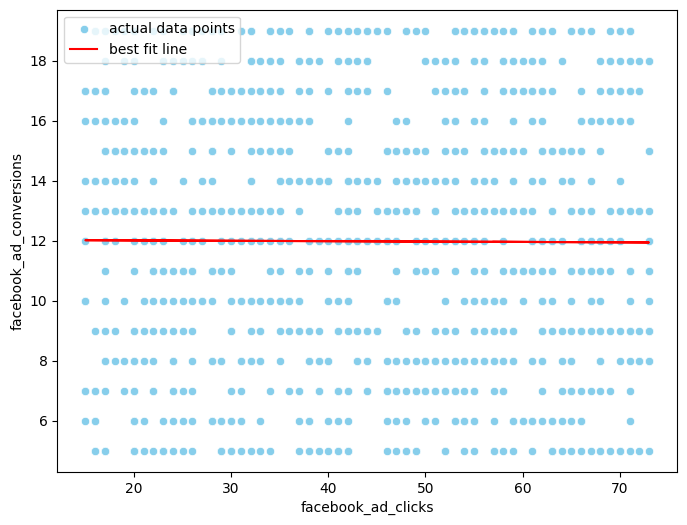

In [31]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["facebook_ad_clicks"],y=df["facebook_ad_conversions"],color="skyblue",label ="actual data points")
plt.plot(df["facebook_ad_clicks"],predictions,color="red",label="best fit line")
plt.legend()
plt.show()

In [32]:
print(f"For 50 clicks, expected conversions: {round(model.predict([[50]])[0], 2)}")
print(f"For 80 clicks, expected conversions: {round(model.predict([[80]])[0], 2)}")


For 50 clicks, expected conversions: 11.97
For 80 clicks, expected conversions: 11.93


Facebook ad clicks have no meaningful effect on conversions.The tiny difference is due to noise.

Both Facebook and AdWords clicks, when considered individually, do not show a strong linear relationship with conversions. The horizontally scattered data points indicate that click volume alone is not a sufficient predictor of conversions.

On the bases of conversion_rate we will get to know which platform is better for campaign. so far due to clicks we have not got idea of better platformBased on the conversion rate, we can determine which platform performs better for the campaign. Click data alone has not provided clear insights so far.

In [33]:
fb_mean_rate = df["facebook_conversion_rate"].mean()
ad_mean_rate = df["adword_conversion_rate"].mean()

print("Facebook mean conversion rate:", round(fb_mean_rate, 4))
print("AdWords mean conversion rate:", round(ad_mean_rate, 4))


Facebook mean conversion rate: 32.6961
AdWords mean conversion rate: 10.8075


Based on average conversion rates, Facebook demonstrates significantly higher efficiency than AdWords in converting clicks into conversions (32.7% vs 10.8%). This suggests Facebook is the more effective platform for conversion-focused campaigns within the observed period.

## Analysis facebook campaign metrics over time

In [34]:
#only facebook dataset
df=df[['date_of_campaign', 'facebook_ad_campaign', 'facebook_ad_views',
       'facebook_ad_clicks', 'facebook_ad_conversions', 'facebook_cost_per_ad',
       'facebook_ctr', 'facebook_conversion_rate', 'facebook_cost_per_click']]
df.head()

,date_of_campaign,facebook_ad_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click
0,2021-12-22,FACEBOOK AD,3172,62,14,141,1.95,22.58,2.27
1,2021-12-24,FACEBOOK AD,3211,38,9,186,1.18,23.68,4.89
2,2021-12-25,FACEBOOK AD,1936,53,15,66,2.74,28.30,1.25
3,2021-12-25,FACEBOOK AD,1194,45,9,71,3.77,20.00,1.58
4,2021-12-26,FACEBOOK AD,2479,44,12,174,1.77,27.27,3.95


### At what time of month or days of week we observe conversion.

In [35]:
#extracting weekdays and months
df['month']=df['date_of_campaign'].dt.month
df['weekday']=df['date_of_campaign'].dt.day_name()

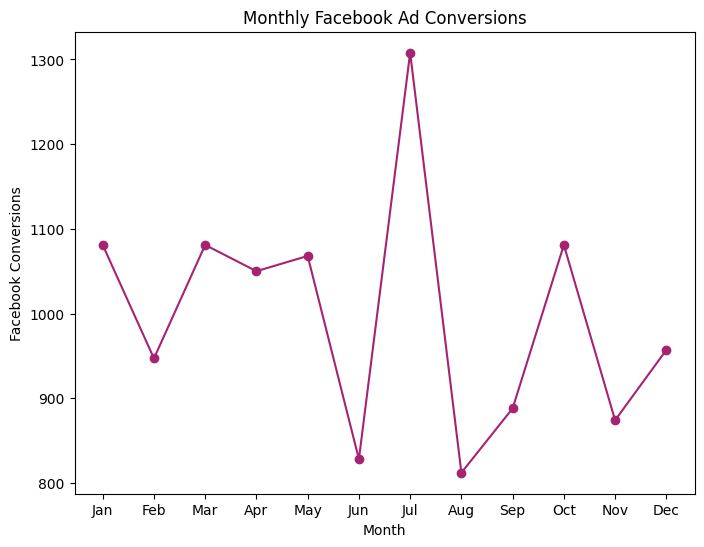

In [36]:
plt.figure(figsize=(8,6))

monthly_conversion = (
    df.groupby("month")["facebook_ad_conversions"]
      .sum()
      .reset_index()
      .sort_values("month")
)

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

plt.plot(
    month_names,
    monthly_conversion["facebook_ad_conversions"],
    "-o",
    color="#A62372"
)

plt.xlabel("Month")
plt.ylabel("Facebook Conversions")
plt.title("Monthly Facebook Ad Conversions")
plt.show()


Facebook ad conversions vary significantly across months, with a peak in July and lower performance during June and August. This indicates strong seasonal or campaign-specific effects, suggesting that time-based factors play a more important role in driving conversions than click volume alone.

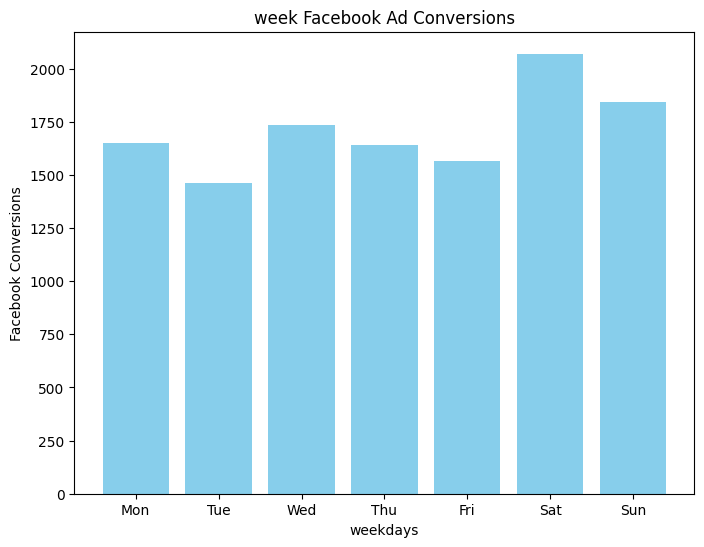

In [37]:
plt.figure(figsize=(8,6))

weekly_conversion = (
    df.groupby("weekday")["facebook_ad_conversions"]
      .sum()
      .reset_index()
      .sort_values("weekday")
)

week_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

plt.bar(
    week_names,
    weekly_conversion["facebook_ad_conversions"],
    color="skyblue"
)

plt.xlabel("weekdays")
plt.ylabel("Facebook Conversions")
plt.title("week Facebook Ad Conversions")
plt.show()


Facebook ad conversions are significantly higher on weekends, particularly on Saturday and Sunday, while mid-week days such as Tuesday show lower performance. This suggests that weekend targeting may yield better conversion outcomes for Facebook campaigns

### How does the Cost Per Conversion (CPC) trend over time?
Cost Per Conversion (CPC): This metric is used to evaluate the cost effectiveness and profitability of an online advertising campaign. This metric helps marketers understand how much they are spending to obtain each conversion, allowing them to optimize their spending and targeting strategies effectively.

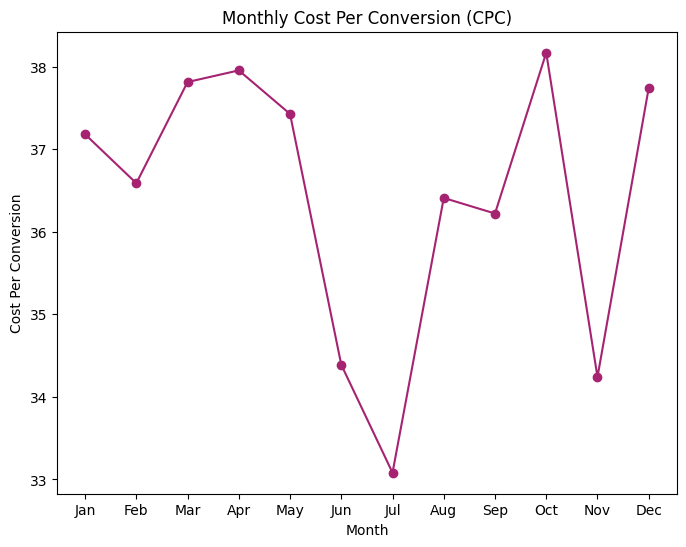

In [38]:
plt.figure(figsize=(8,6))
plt.title('Monthly Cost Per Conversion (CPC)')

monthly_df = df.groupby('month')[['facebook_cost_per_click', 'facebook_cost_per_ad']].sum().reset_index().sort_values("month")

monthly_df['facebook_cost_per_click'] = (
    monthly_df['facebook_cost_per_ad'] / monthly_df['facebook_cost_per_click']
)

plt.plot(month_names, monthly_df['facebook_cost_per_click'],"-o",color="#A62372",)
plt.xlabel('Month')
plt.ylabel('Cost Per Conversion')
plt.show()


July is the most cost-effective month → good time to scale ads

October & December are more expensive → optimize targeting or budget carefully

Seasonal demand likely impacts CPC

**Is there a long-term equilibrium relationship between advertising spend and conversion rates that suggests a stable, proportional impact of budget changes on conversions over time?**

In [39]:
score, p_value, _ = coint(df['facebook_cost_per_ad'], df['facebook_cost_per_click'])

print('Cointegration test score:', score)
print('P-value:', p_value)

if p_value < 0.05:
    print("p-value is less than significance value, Reject the null hypothesis")
else:
    print("\np-value is greater than significance value, Accept the null hypothesis")


Cointegration test score: -20.967644643192628
P-value: 0.0
p-value is less than significance value, Reject the null hypothesis


Since the p-value is significantly lower than the chosen significance level, we reject the null hypothesis. This indicates that there is a long-term equilibrium relationship between advertising spend (cost) and conversions.

Businesses can use this understanding of the stable relationship between cost and conversions to optimize their advertising strategies. By investing in campaigns that demonstrate a strong return on investment (ROI) and adjusting spending based on performance, companies can maximize conversions while minimizing costs.